# Memorization vs Learning in Fluoroquinolone Resistance Prediction

Analysis showing how non-singleton approaches achieve misleading performance through memorization rather than biological understanding.

In [1]:
# import os

# repo_url = "https://github.com/viktoria023/thesis-repository.git"
# repo_dir = "thesis-repository/predict_FQ_resistance"

# if not os.path.exists(repo_dir):
#     !git clone {repo_url}

# %cd {repo_dir}

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics 
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.gridspec import GridSpec

import seaborn as sns
from xgboost import XGBClassifier

Check resistance mutation distribution

In [3]:
# Make a table of the most common mutations in each dataset, with one column for LEV and one for MXF
lev_data = pd.read_csv('data/ML_DATA_LEV.csv')
lev_mutations = lev_data.GENE_MUTATION.value_counts().reset_index()
lev_mutations.columns = ['GENE_MUTATION', 'LEV_count']
mxf_data = pd.read_csv('data/ML_DATA_MXF.csv')
mxf_mutations = mxf_data.GENE_MUTATION.value_counts().reset_index()
mxf_mutations.columns = ['GENE_MUTATION', 'MXF_count']
common_mutations = pd.merge(lev_mutations, mxf_mutations, how='outer', on='GENE_MUTATION').fillna(0)
common_mutations['LEV_count'] = common_mutations['LEV_count'].astype(int)
common_mutations['MXF_count'] = common_mutations['MXF_count'].astype(int)
common_mutations['total %'] = round((common_mutations['LEV_count'] + common_mutations['MXF_count']) / (sum(lev_mutations['LEV_count']) + sum(mxf_mutations['MXF_count'])) * 100, 2)
common_mutations.sort_values(by='LEV_count', ascending=False, inplace=True)
common_mutations.rename(columns={'GENE_MUTATION':'Mutation','LEV_count': 'Levofloxacin', 'MXF_count': 'Moxifloxacin'}, inplace=True)
common_mutations[:15].to_latex(index=False)

'\\begin{tabular}{lrrr}\n\\toprule\nMutation & Levofloxacin & Moxifloxacin & total % \\\\\n\\midrule\ngyrA_D94G & 632 & 621 & 36.120000 \\\\\ngyrA_A90V & 340 & 338 & 19.540000 \\\\\ngyrA_D94N & 137 & 138 & 7.930000 \\\\\ngyrA_D94A & 85 & 88 & 4.990000 \\\\\ngyrA_S91P & 63 & 67 & 3.750000 \\\\\ngyrA_D94Y & 60 & 62 & 3.520000 \\\\\ngyrA_D94H & 38 & 35 & 2.100000 \\\\\ngyrA_N193S & 27 & 20 & 1.350000 \\\\\ngyrA_P472S & 23 & 14 & 1.070000 \\\\\ngyrA_G88C & 22 & 24 & 1.330000 \\\\\ngyrB_E501D & 18 & 17 & 1.010000 \\\\\ngyrA_T267I & 12 & 12 & 0.690000 \\\\\ngyrB_D461N & 10 & 13 & 0.660000 \\\\\ngyrA_P154R & 9 & 9 & 0.520000 \\\\\ngyrB_R446C & 9 & 10 & 0.550000 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [4]:
for i,gene in enumerate(mxf_data.GENE_MUTATION.value_counts()[:10].items()):
    print(f"Rank {i+1}: {gene[0]} with {gene[1]} occurrences")
    #percentage of total
    print(f"Percentage of total: {gene[1]/sum(mxf_data.GENE_MUTATION.value_counts())*100:.2f}%\n")
    print(f"cumulative percentage of total: {sum(mxf_data.GENE_MUTATION.value_counts()[:i+1])/sum(mxf_data.GENE_MUTATION.value_counts())*100:.2f}%\n")

Rank 1: gyrA_D94G with 621 occurrences
Percentage of total: 36.44%

cumulative percentage of total: 36.44%

Rank 2: gyrA_A90V with 338 occurrences
Percentage of total: 19.84%

cumulative percentage of total: 56.28%

Rank 3: gyrA_D94N with 138 occurrences
Percentage of total: 8.10%

cumulative percentage of total: 64.38%

Rank 4: gyrA_D94A with 88 occurrences
Percentage of total: 5.16%

cumulative percentage of total: 69.54%

Rank 5: gyrA_S91P with 67 occurrences
Percentage of total: 3.93%

cumulative percentage of total: 73.47%

Rank 6: gyrA_D94Y with 62 occurrences
Percentage of total: 3.64%

cumulative percentage of total: 77.11%

Rank 7: gyrA_D94H with 35 occurrences
Percentage of total: 2.05%

cumulative percentage of total: 79.17%

Rank 8: gyrA_G88C with 24 occurrences
Percentage of total: 1.41%

cumulative percentage of total: 80.58%

Rank 9: gyrA_N193S with 20 occurrences
Percentage of total: 1.17%

cumulative percentage of total: 81.75%

Rank 10: gyrB_E501D with 17 occurrences


In [5]:
for i,gene in enumerate(lev_data.GENE_MUTATION.value_counts()[:10].items()):
    print(f"Rank {i+1}: {gene[0]} with {gene[1]} occurrences")
    #percentage of total
    print(f"Percentage of total: {gene[1]/sum(lev_data.GENE_MUTATION.value_counts())*100:.2f}%\n")
    print(f"cumulative percentage of total: {sum(lev_data.GENE_MUTATION.value_counts()[:i+1])/sum(lev_data.GENE_MUTATION.value_counts())*100:.2f}%\n")

Rank 1: gyrA_D94G with 632 occurrences
Percentage of total: 35.81%

cumulative percentage of total: 35.81%

Rank 2: gyrA_A90V with 340 occurrences
Percentage of total: 19.26%

cumulative percentage of total: 55.07%

Rank 3: gyrA_D94N with 137 occurrences
Percentage of total: 7.76%

cumulative percentage of total: 62.83%

Rank 4: gyrA_D94A with 85 occurrences
Percentage of total: 4.82%

cumulative percentage of total: 67.65%

Rank 5: gyrA_S91P with 63 occurrences
Percentage of total: 3.57%

cumulative percentage of total: 71.22%

Rank 6: gyrA_D94Y with 60 occurrences
Percentage of total: 3.40%

cumulative percentage of total: 74.62%

Rank 7: gyrA_D94H with 38 occurrences
Percentage of total: 2.15%

cumulative percentage of total: 76.77%

Rank 8: gyrA_N193S with 27 occurrences
Percentage of total: 1.53%

cumulative percentage of total: 78.30%

Rank 9: gyrA_P472S with 23 occurrences
Percentage of total: 1.30%

cumulative percentage of total: 79.60%

Rank 10: gyrA_G88C with 22 occurrences


## Part 1: Non-singleton approach with duplicate samples

In [6]:
# Load data with all duplicate mutations
data = pd.read_csv('data/ML_DATA_MXF.csv')
# data = pd.read_csv('data/ML_DATA_LEV.csv')
#only drop if nans are in the feature columns
data.dropna(inplace=True, subset = ['CLEAN_BINARY_PHENOTYPE','d_volume', 'd_hydropathy_KD', 'd_hydropathy_WW', 'd_MW', 'd_Pi', 'secondary_structure',
                                    'secondary_structure_long', 'phi', 'psi', 'residue_sasa', 'n_hbond_acceptors', 'n_hbond_donors', 'B', 'C', 'E',
                                    'G', 'H', 'T', 'SASA', 'snap2_score', 'snap2_accuracy', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG'])

# data.dropna(inplace=True)

print("Total samples with duplicates:", len(data))
print("Total resistant samples:", len(data[data.CLEAN_BINARY_PHENOTYPE == 'R']))
print("Total susceptible samples:", len(data[data.CLEAN_BINARY_PHENOTYPE == 'S']))
print("Unique mutations:", data.GENE_MUTATION.nunique())
print("Unique resistant mutations:", data[data.CLEAN_BINARY_PHENOTYPE == 'R'].GENE_MUTATION.nunique())
print("Unique susceptible mutations:", data[data.CLEAN_BINARY_PHENOTYPE == 'S'].GENE_MUTATION.nunique())
print("Average samples per mutation:", len(data)/data.GENE_MUTATION.nunique())

data.CLEAN_BINARY_PHENOTYPE.value_counts()

Total samples with duplicates: 1695
Total resistant samples: 1420
Total susceptible samples: 275
Unique mutations: 153
Unique resistant mutations: 23
Unique susceptible mutations: 133
Average samples per mutation: 11.07843137254902


CLEAN_BINARY_PHENOTYPE
R    1420
S     275
Name: count, dtype: int64

In [7]:
# Prepare features and labels
features = ['d_volume', 'd_hydropathy_KD', 'd_hydropathy_WW',
       'd_MW', 'd_Pi', 'secondary_structure', 'phi', 'psi', 'residue_sasa', 
       'n_hbond_acceptors', 'n_hbond_donors', 'SASA', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG'] # 'B', 'C', 'E', 'G', 'H', 'T',

features_LEV = [
       'd_MW', 'd_Pi', 'secondary_structure', 'phi', 
       'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG']

features_MXF = ['d_volume',
       'd_MW', 'd_Pi', 'secondary_structure', 'psi',
       'n_hbond_acceptors', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor']


true_label = data.CLEAN_BINARY_PHENOTYPE
features = data[features_MXF].copy()
# features = data[features_LEV].copy()
features['secondary_structure_codes'] = pd.Categorical(features.secondary_structure, 
                                                      categories=features.secondary_structure.unique()).codes
features.drop('secondary_structure', inplace=True, axis=1)

replacement = {"R": 1, "S": 0}
y = true_label.replace(replacement)

random_seed = 24
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.30, random_state=random_seed)

In [8]:
# model selection with cross-validation
random_seed = 24

folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)

param_grid = [ 
                {   'penalty': ['l2'],
                    'solver'  : ['newton-cg', 'lbfgs', 'liblinear', 'newton-cholesky', 'sag', 'saga'], 
                    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                    'class_weight' : ['balanced', None]
                } 
            ]

gsvc_lr = GridSearchCV(LogisticRegression(random_state=random_seed), 
                    param_grid, 
                    cv = folds, 
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'
gsvc_lr.fit(X_train,y_train)

gsvc_lr.best_params_

/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

{'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'newton-cg'}

In [9]:
folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)

model_xgb = XGBClassifier()

param_grid = [ 
        {   'n_estimators': [25, 50, 100, 150, 200],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1],
            'max_depth':[2,4,5,6,8],
            'min_child_weight': [0, 0.1, 1, 10],
            'learning_rate':[0.005, 0.01, 0.05, 0.075, 0.1, 0.125, 0.1] } 
    ]

gsvc_xgb = GridSearchCV(model_xgb, 
                    param_grid, 
                    cv = folds, 
                    n_jobs=-1,
                    return_train_score=True,
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'

gsvc_xgb.fit(X_train,y_train)
gsvc_xgb.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=0, missing=nan, monotone_constraints=None,
              n_estimators=150, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [10]:
# Use the best estimators from GridSearchCV
logreg_optimized = gsvc_lr.best_estimator_
xgb_optimized = gsvc_xgb.best_estimator_

logreg_optimized.fit(X_train, y_train)
xgb_optimized.fit(X_train, y_train)

y_pred_lr = logreg_optimized.predict(X_test)
y_pred_xgb = xgb_optimized.predict(X_test)

print("Logistic Regression accuracy:", metrics.accuracy_score(y_test, y_pred_lr))
print("XGBoost accuracy:", metrics.accuracy_score(y_test, y_pred_xgb))

# Calculate sensitivity and specificity for non-singleton approach
cnf_matrix_lr = metrics.confusion_matrix(y_test, y_pred_lr)
cnf_matrix_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)

if cnf_matrix_lr.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr.ravel()
    sensitivity_lr = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_lr = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"LR Sensitivity (resistance detection): {sensitivity_lr:.3f}")
    print(f"LR Specificity (susceptible detection): {specificity_lr:.3f}")

if cnf_matrix_xgb.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_xgb.ravel()
    sensitivity_xgb = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"XGB Sensitivity (resistance detection): {sensitivity_xgb:.3f}")
    print(f"XGB Specificity (susceptible detection): {specificity_xgb:.3f}")

Logistic Regression accuracy: 0.9724950884086444
XGBoost accuracy: 0.9862475442043221
LR Sensitivity (resistance detection): 0.990
LR Specificity (susceptible detection): 0.889
XGB Sensitivity (resistance detection): 0.990
XGB Specificity (susceptible detection): 0.967


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_12433/2280756186.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


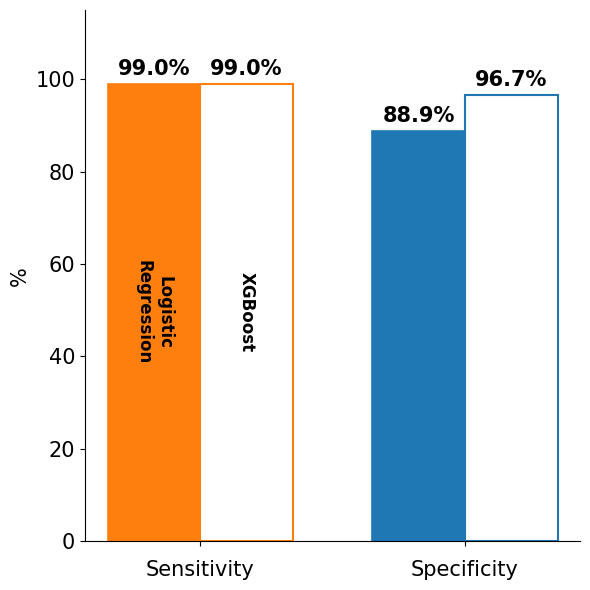

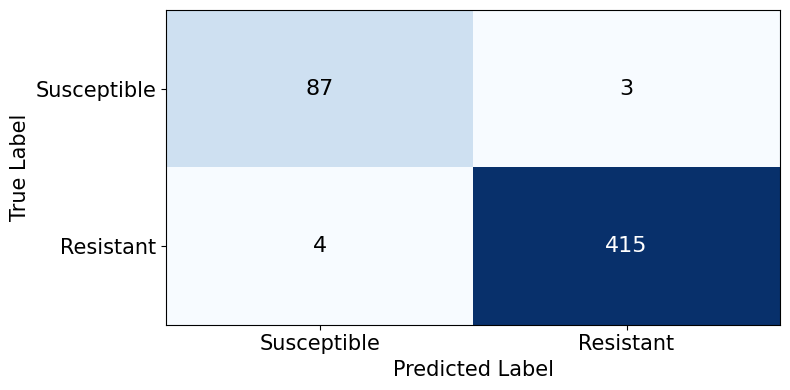

In [11]:
# Plot sensitivity and specificity with enhanced styling (matching reference plot style)
x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Colors matching your original plot but with the professional styling
blue = '#1f77b4'    # Sensitivity (tab:blue equivalent)
orange = '#ff7f0e'  # Specificity (tab:orange equivalent)

# Bar values for both models
lr_values = [sensitivity_lr, specificity_lr]  # Logistic Regression
xgb_values = [sensitivity_xgb, specificity_xgb]  # XGBoost

# Create bars with filled and hollow styling
bars_lr = ax.bar(x_pos - bar_width/2, lr_values, width=bar_width,
                 color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)

bars_xgb = ax.bar(x_pos + bar_width/2, xgb_values, width=bar_width,
                  color='white', edgecolor=[orange, blue], linewidth=1.5)

# Add percentage labels above bars
for bar, val in zip(list(bars_lr) + list(bars_xgb), lr_values + xgb_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add model labels inside bars (rotated)
model_labels_lr = ['Logistic\nRegression', '']
model_labels_xgb = ['XGBoost', '']

for i in range(2):  # 0 = sensitivity, 1 = specificity
    if model_labels_lr[i]:
        bar = bars_lr[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_lr[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')
    if model_labels_xgb[i]:
        bar = bars_xgb[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_xgb[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')

# Set labels and styling
ax.set_xticks(x_pos)
ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
ax.xaxis.set_tick_params(pad=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('%', fontsize=15)

# Format y-axis as percentages
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)

# Clean styling - remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
# plt.savefig('pdf/overall_performance_sen_spec.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

# Keep the confusion matrix visualization
fig, ax2 = plt.subplots(figsize=(8, 4))
cm = cnf_matrix_xgb
im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, aspect='auto')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=16)

ax2.set_ylabel('True Label', fontsize=15)
ax2.set_xlabel('Predicted Label', fontsize=15)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Susceptible', 'Resistant'], fontsize=15)
ax2.set_yticklabels(['Susceptible', 'Resistant'], fontsize=15)

# Force the aspect ratio to be rectangular (2:1)
ax2.set_aspect('auto')

plt.tight_layout()
# plt.savefig('pdf/XGBoost_confusion_matrix.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

In [12]:
# check out the misclassified resistant samples in XGBoost
misclassified_indices = X_test[((y_test == 1) & (y_pred_xgb == 0))|((y_test == 0) & (y_pred_xgb == 1))].index
misclassified_samples = data.loc[misclassified_indices]
print("Misclassified resistant samples:\n", misclassified_samples)

Misclassified resistant samples:
       index DRUG  MIC  LOG2MIC BINARY_PHENOTYPE PHENOTYPE_QUALITY  GENE  \
1303   1303  MXF  2.0      1.0                R              HIGH  gyrB   
711     711  MXF  0.5     -1.0                S            MEDIUM  gyrA   
1453   1453  MXF  4.0      2.0                R              HIGH  gyrB   
1441   1441  MXF  2.0      1.0                R              HIGH  gyrA   
1695   1695  MXF  NaN      NaN              NaN               NaN  gyrA   
1021   1021  MXF  4.0      2.0                R              HIGH  gyrA   
1699   1699  MXF  NaN      NaN              NaN               NaN  gyrA   

      POSITION GENE_MUTATION CLEAN_BINARY_PHENOTYPE  ...      T       SASA  \
1303     618.0    gyrB_A618D                      R  ...  False  13.710548   
711       88.0     gyrA_G88A                      S  ...  False   9.936179   
1453     509.0    gyrB_L509P                      R  ...  False   0.342219   
1441     490.0    gyrA_H490R                      R  

In [13]:
# check if these misclassified samples have mutations that were not in the training set
train_mutations = set(data.loc[X_train.index, 'GENE_MUTATION'])
test_mutations = set(data.loc[X_test.index, 'GENE_MUTATION'])
misclassified_mutations = set(misclassified_samples['GENE_MUTATION'])
unseen_mutations = misclassified_mutations - train_mutations
print("Unseen mutations in misclassified samples:", unseen_mutations)
print("Out of", len(misclassified_mutations), "misclassified mutations,",len(unseen_mutations),"are not present in the training set.")

Unseen mutations in misclassified samples: {'gyrB_L509P', 'gyrA_A288D', 'gyrA_A90G', 'gyrA_S95T', 'gyrA_H490R', 'gyrB_A618D'}
Out of 7 misclassified mutations, 6 are not present in the training set.


## Part 2: Data leakage analysis

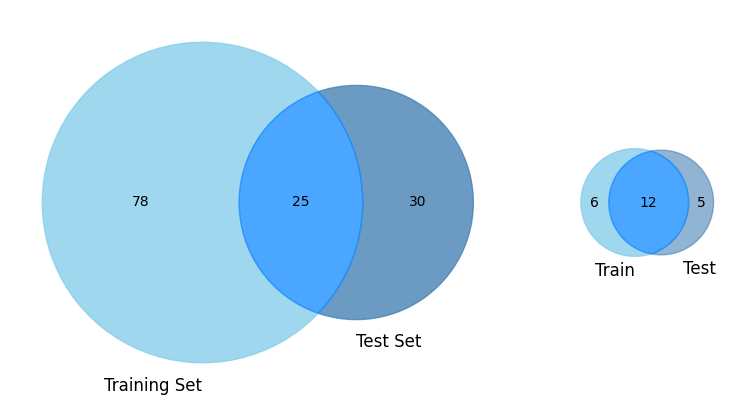

In [14]:
# Prepare data
train_data = data.loc[X_train.index]
test_data = data.loc[X_test.index]

train_susceptible = set(train_data[train_data.CLEAN_BINARY_PHENOTYPE == 'S']['GENE_MUTATION'])
test_susceptible = set(test_data[test_data.CLEAN_BINARY_PHENOTYPE == 'S']['GENE_MUTATION'])

train_resistant = set(train_data[train_data.CLEAN_BINARY_PHENOTYPE == 'R']['GENE_MUTATION'])
test_resistant = set(test_data[test_data.CLEAN_BINARY_PHENOTYPE == 'R']['GENE_MUTATION'])

# Create figure with tighter grid
fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, width_ratios=[4, 1])  # 4:1 ratio = second diagram is ~1/4 width of first

# First (larger) Venn diagram – Susceptible
ax1 = fig.add_subplot(gs[0])
venn_s = venn2([train_susceptible, test_susceptible], 
               set_labels=('Training Set', 'Test Set'), ax=ax1)

if venn_s.get_patch_by_id('10'):
    venn_s.get_patch_by_id('10').set_color('#87CEEB')
    venn_s.get_patch_by_id('10').set_alpha(0.8)
if venn_s.get_patch_by_id('01'):
    venn_s.get_patch_by_id('01').set_color('#4682B4')
    venn_s.get_patch_by_id('01').set_alpha(0.8)
if venn_s.get_patch_by_id('11'):
    venn_s.get_patch_by_id('11').set_color('#1E90FF')
    venn_s.get_patch_by_id('11').set_alpha(0.8)

# Second (smaller) Venn diagram – Resistant
ax2 = fig.add_subplot(gs[1])
venn_r = venn2([train_resistant, test_resistant], 
               set_labels=('Train', 'Test'), ax=ax2)

# Color patches
if venn_r.get_patch_by_id('10'):
    venn_r.get_patch_by_id('10').set_color('#87CEEB')
    venn_r.get_patch_by_id('10').set_alpha(0.8)
if venn_r.get_patch_by_id('01'):
    venn_r.get_patch_by_id('01').set_color('#4682B4')
    venn_r.get_patch_by_id('01').set_alpha(0.6)
if venn_r.get_patch_by_id('11'):
    venn_r.get_patch_by_id('11').set_color('#1E90FF')
    venn_r.get_patch_by_id('11').set_alpha(0.8)

# Move "Test" label 
label = venn_r.set_labels[1]  
label.set_x(label.get_position()[0] + 0.2)  # shift right 

# Tighten spacing between subplots
plt.subplots_adjust(wspace=0.01)
# plt.savefig('pdf/mutation_overlap.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

## Part 3: Testing with singleton approach

In [15]:
# Create singleton dataset - one sample per mutation
data_singleton = data.drop_duplicates(subset=['GENE_MUTATION'], keep='first')

print("Singleton samples:", len(data_singleton))
print("Original samples:", len(data))
print("Reduction factor:", len(data) / len(data_singleton))

singleton_counts = data_singleton.CLEAN_BINARY_PHENOTYPE.value_counts()
print("\nSingleton class distribution:")
print(singleton_counts)
print("Resistance rate:", singleton_counts['R'] / len(data_singleton))

Singleton samples: 153
Original samples: 1695
Reduction factor: 11.07843137254902

Singleton class distribution:
CLEAN_BINARY_PHENOTYPE
S    133
R     20
Name: count, dtype: int64
Resistance rate: 0.13071895424836602


In [16]:
# Prepare singleton features
true_label_singleton = data_singleton.CLEAN_BINARY_PHENOTYPE
features_singleton = data_singleton[features_MXF].copy()
features_singleton = data_singleton[features_LEV].copy()
features_singleton['secondary_structure_codes'] = pd.Categorical(
    features_singleton.secondary_structure, 
    categories=features_singleton.secondary_structure.unique()).codes
features_singleton.drop('secondary_structure', inplace=True, axis=1)

y_singleton = true_label_singleton.replace(replacement)

# Nested Cross-Validation for robust performance estimation

In [17]:
# Nested Cross-Validation for robust performance estimation
# Outer CV: Performance estimation (Train:Test split), Inner CV: Hyperparameter optimization

random_seed=24

# Define nested CV structure
outer_cv = StratifiedKFold(n_splits=3, random_state=random_seed, shuffle=True)  # Outer loop for performance estimation
inner_cv = StratifiedKFold(n_splits=5, random_state=random_seed, shuffle=True)  # Inner loop for hyperparameter tuning

# Parameter grids (simplified for faster nested CV)
lr_param_grid = {
    'penalty': ['l2'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'newton-cholesky', 'sag', 'saga'], 
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'class_weight': ['balanced', None]
}

xgb_param_grid = {
    'n_estimators': [25, 50, 100, 150, 200],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [2, 4, 6, 8],
    'min_child_weight': [0, 0.1, 1, 10],
    'learning_rate': [0.005, 0.01, 0.05, 0.075, 0.1, 0.125, 0.1]
}

# Storage for results
lr_test_sens, lr_test_spec, lr_test_acc = [], [], []
xgb_test_sens, xgb_test_spec, xgb_test_acc = [], [], []
lr_train_sens, lr_train_spec, lr_train_acc = [], [], []
xgb_train_sens, xgb_train_spec, xgb_train_acc = [], [], []

# Storage for confusion matrices
lr_test_cms = []
xgb_test_cms = []

print("Starting Nested Cross-Validation...")
print("Outer CV: 3 folds, Inner CV: 5 folds")
print("Using full singleton dataset for nested CV")
print("This may take a few minutes...")

fold_count = 0
for train_idx, test_idx in outer_cv.split(features_singleton, y_singleton):
    fold_count += 1
    print(f"\nProcessing outer fold {fold_count}/3...")
    
    # Split data for this outer fold using the full singleton dataset
    X_train_outer, X_test_outer = features_singleton.iloc[train_idx], features_singleton.iloc[test_idx]
    y_train_outer, y_test_outer = y_singleton.iloc[train_idx], y_singleton.iloc[test_idx]

    # --- Logistic Regression ---
    lr_clf = GridSearchCV(
        LogisticRegression(random_state=random_seed),
        lr_param_grid,
        cv=inner_cv,
        scoring='recall',  # Optimize for sensitivity
        n_jobs=-1
    )
    lr_clf.fit(X_train_outer, y_train_outer)
    
    # Test predictions
    y_pred_lr_test = lr_clf.predict(X_test_outer)
    y_pred_lr_train = lr_clf.predict(X_train_outer)
    
    # Test performance
    cm_test = metrics.confusion_matrix(y_test_outer, y_pred_lr_test, labels=[0,1])
    lr_test_cms.append(cm_test)  # Store confusion matrix
    
    if cm_test.shape == (2, 2):
        tn, fp, fn, tp = cm_test.ravel()
        lr_test_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        lr_test_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        lr_test_acc.append((tp + tn) / (tp + tn + fp + fn))
    
    # Train performance
    cm_train = metrics.confusion_matrix(y_train_outer, y_pred_lr_train, labels=[0,1])
    if cm_train.shape == (2, 2):
        tn, fp, fn, tp = cm_train.ravel()
        lr_train_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        lr_train_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        lr_train_acc.append((tp + tn) / (tp + tn + fp + fn))
    
    # --- XGBoost ---
    xgb_clf = GridSearchCV(
        XGBClassifier(random_state=random_seed),
        xgb_param_grid,
        cv=inner_cv,
        scoring='recall',  # Optimize for sensitivity
        n_jobs=-1
    )
    xgb_clf.fit(X_train_outer, y_train_outer)
    
    # Test predictions
    y_pred_xgb_test = xgb_clf.predict(X_test_outer)
    y_pred_xgb_train = xgb_clf.predict(X_train_outer)
    
    # Test performance
    cm_test = metrics.confusion_matrix(y_test_outer, y_pred_xgb_test, labels=[0,1])
    xgb_test_cms.append(cm_test)  # Store confusion matrix
    
    if cm_test.shape == (2, 2):
        tn, fp, fn, tp = cm_test.ravel()
        xgb_test_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        xgb_test_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        xgb_test_acc.append((tp + tn) / (tp + tn + fp + fn))
    
    # Train performance
    cm_train = metrics.confusion_matrix(y_train_outer, y_pred_xgb_train, labels=[0,1])
    if cm_train.shape == (2, 2):
        tn, fp, fn, tp = cm_train.ravel()
        xgb_train_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        xgb_train_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        xgb_train_acc.append((tp + tn) / (tp + tn + fp + fn))

print("\nLogistic Regression Test Confusion Matrices:")
for i, cm in enumerate(lr_test_cms):
    print(f"  Fold {i+1}:")
    print(f"    [[{cm[0,0]:2d} {cm[0,1]:2d}]")
    print(f"     [{cm[1,0]:2d} {cm[1,1]:2d}]]")

print("\nXGBoost Test Confusion Matrices:")
for i, cm in enumerate(xgb_test_cms):
    print(f"  Fold {i+1}:")
    print(f"    [[{cm[0,0]:2d} {cm[0,1]:2d}]")
    print(f"     [{cm[1,0]:2d} {cm[1,1]:2d}]]")

Starting Nested Cross-Validation...
Outer CV: 3 folds, Inner CV: 5 folds
Using full singleton dataset for nested CV
This may take a few minutes...

Processing outer fold 1/3...


/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.wa


Processing outer fold 2/3...


/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.wa


Processing outer fold 3/3...


/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.wa


Logistic Regression Test Confusion Matrices:
  Fold 1:
    [[39  5]
     [ 4  3]]
  Fold 2:
    [[35  9]
     [ 1  6]]
  Fold 3:
    [[35 10]
     [ 0  6]]

XGBoost Test Confusion Matrices:
  Fold 1:
    [[44  0]
     [ 6  1]]
  Fold 2:
    [[42  2]
     [ 3  4]]
  Fold 3:
    [[44  1]
     [ 0  6]]


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_12433/384917082.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


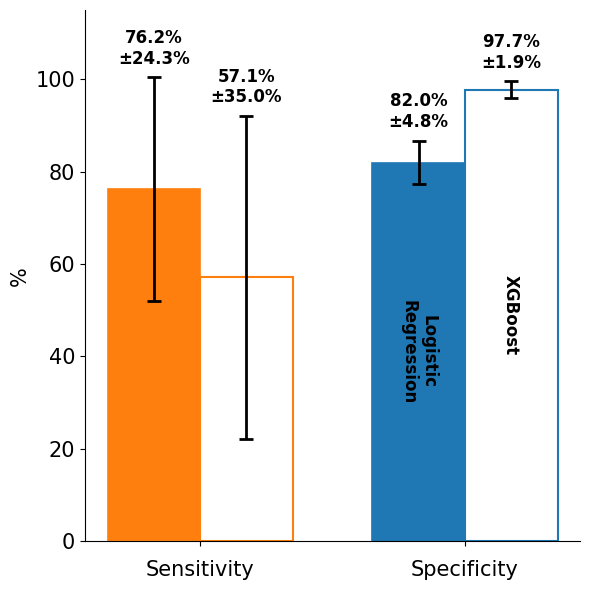

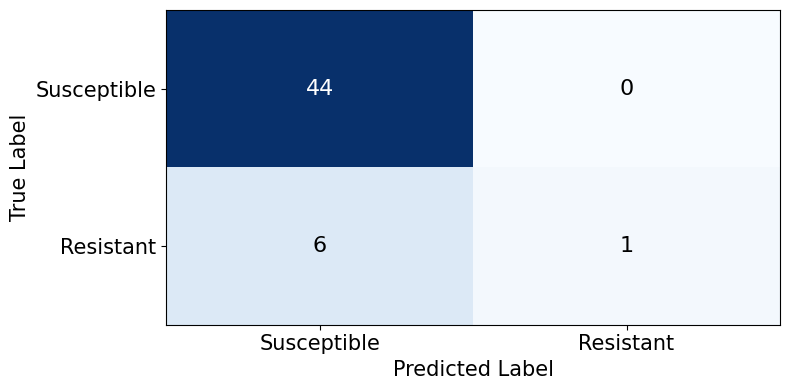

In [18]:
# Plot nested CV sensitivity and specificity with error bars (Singleton Dataset)
x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Colors matching the reference plot styling
blue = '#1f77b4'    # Sensitivity
orange = '#ff7f0e'  # Specificity

# Bar values and standard deviations for both models (nested CV - singleton dataset)
lr_values_cv_s = [np.mean(lr_test_sens), np.mean(lr_test_spec)]  # Logistic Regression
lr_stds_cv_s = [np.std(lr_test_sens), np.std(lr_test_spec)]
xgb_values_cv_s = [np.mean(xgb_test_sens), np.mean(xgb_test_spec)]  # XGBoost
xgb_stds_cv_s = [np.std(xgb_test_sens), np.std(xgb_test_spec)]

# Create bars with filled and hollow styling
bars_lr_cv_s = ax.bar(x_pos - bar_width/2, lr_values_cv_s, width=bar_width,
                      color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2,
                      yerr=lr_stds_cv_s, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

bars_xgb_cv_s = ax.bar(x_pos + bar_width/2, xgb_values_cv_s, width=bar_width,
                       color='white', edgecolor=[orange, blue], linewidth=1.5,
                       yerr=xgb_stds_cv_s, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add percentage labels above bars (above error bars)
for i, (bar, val, std) in enumerate(zip(list(bars_lr_cv_s) + list(bars_xgb_cv_s), 
                                       lr_values_cv_s + xgb_values_cv_s, 
                                       lr_stds_cv_s + xgb_stds_cv_s)):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.02,
            f'{val * 100:.1f}%\n±{std * 100:.1f}%', ha='center', va='bottom', 
            fontsize=12, fontweight='bold')

# Add model labels inside bars (rotated)
model_labels_lr_cv_s = ['', 'Logistic\nRegression']
model_labels_xgb_cv_s = ['', 'XGBoost']

for i in range(2):  # 0 = sensitivity, 1 = specificity
    if model_labels_lr_cv_s[i]:
        bar = bars_lr_cv_s[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_lr_cv_s[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')
    if model_labels_xgb_cv_s[i]:
        bar = bars_xgb_cv_s[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_xgb_cv_s[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')

# Set labels and styling
ax.set_xticks(x_pos)
ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
ax.xaxis.set_tick_params(pad=10)
ax.set_ylim(0, 1.15)  # Increased to accommodate error bars
ax.set_ylabel('%', fontsize=15)

# Format y-axis as percentages
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)

# Clean styling - remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
# plt.savefig('pdf/nested_cv_performance_sen_spec_singleton.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

# Display one confusion matrix for singleton XGBoost
fig, ax2 = plt.subplots(figsize=(8, 4))
cm_s = xgb_test_cms[0] # Use the confusion matrix from the last outer fold
im = ax2.imshow(cm_s, interpolation='nearest', cmap=plt.cm.Blues, aspect='auto')
# ax2.figure.colorbar(im, ax=ax2)

# Add text annotations
thresh = cm_s.max() / 2. if cm_s.max() > 0 else 0.5
for i in range(cm_s.shape[0]):
    for j in range(cm_s.shape[1]):
        ax2.text(j, i, format(cm_s[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_s[i, j] > thresh else "black", fontsize=16)

ax2.set_ylabel('True Label', fontsize=15)
ax2.set_xlabel('Predicted Label', fontsize=15)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Susceptible', 'Resistant'], fontsize=15)
ax2.set_yticklabels(['Susceptible', 'Resistant'], fontsize=15)

# Force the aspect ratio to be rectangular (2:1)
ax2.set_aspect('auto')

plt.tight_layout()
# plt.savefig('pdf/XGBoost_confusion_matrix_singleton.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()